<a href="https://colab.research.google.com/github/Javier-System-Data/Proyecto-Titanic/blob/main/Titanic_Data1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Instalción de paquete ptitprince
!pip install ptitprince


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 26.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptitprince: filename=ptitprince-0.3.1-py3-none-any.whl size=16216 sha256=105e89d267ea4866ff12c3c7e3b95bca15e958ab1ca298b61b4ed06251882ae4
  Stored in directory: /root/.cache/pip/wheels/5d/79/49/b89a41fd3d8780ce2c21c7f2debe45f3c6b08d8aef400e3df1
Successfully built ptitprince


In [2]:
#Verificar que la instalación del paquete ha sido exitosa:
try:
    import ptitprince as pt
    import seaborn as sns
    print(f"Instalación exitosa. Versión de Seaborn: {sns.__version__}")
except ImportError:
    print("Algo salió mal, verifica la instalación.")

Instalación exitosa. Versión de Seaborn: 0.13.2


/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


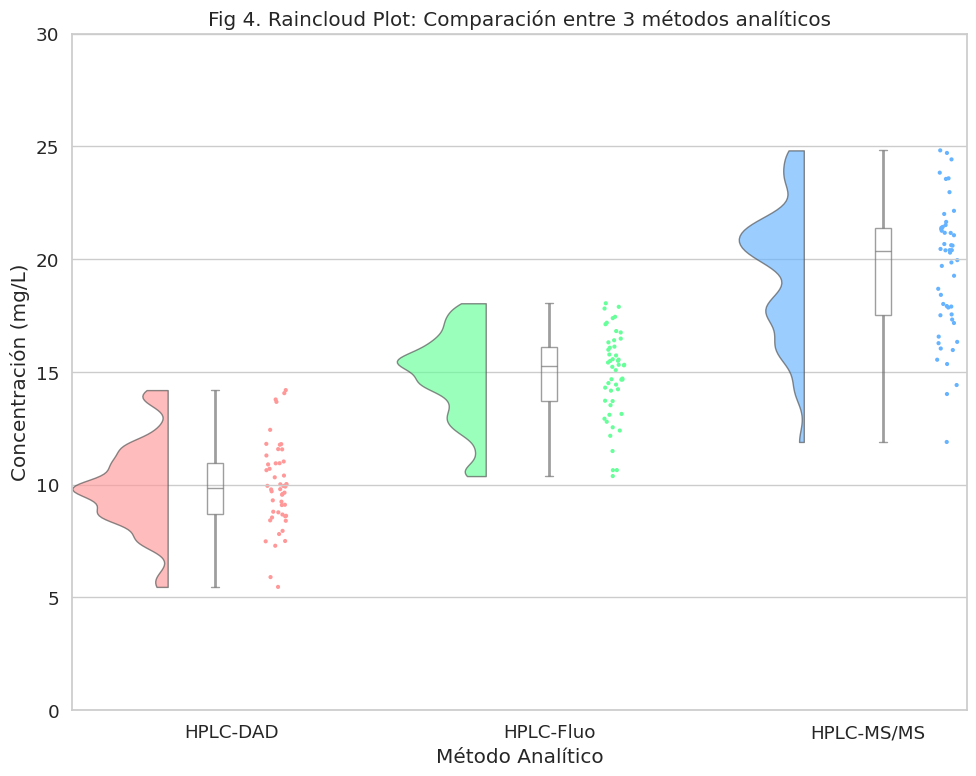

In [3]:
#----------------------------------------------------------------------------------
# DATA PARA PRACTICAR
#----------------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns

# 1. Creamos datos de ejemplo similares a tu imagen
data = {
    'Método Analítico': (['HPLC-DAD'] * 50 + ['HPLC-Fluo'] * 50 + ['HPLC-MS/MS'] * 50),
    'Concentración (mg/L)': (
        np.random.normal(10, 2, 50).tolist() +  # DAD: media 10
        np.random.normal(15, 2.5, 50).tolist() + # Fluo: media 15
        np.random.normal(20, 3, 50).tolist()    # MS/MS: media 20
    )
}
df = pd.DataFrame(data)

# 2. Configuración estética
sns.set(style="whitegrid", font_scale=1.2)
colors = ["#ff9999", "#66ff99", "#66b3ff"] # Colores pastel similares a tu imagen

# 3. Creación del Raincloud Plot
f, ax = plt.subplots(figsize=(10, 8))

pt.RainCloud(
    x = 'Método Analítico',
    y = 'Concentración (mg/L)',
    data = df,
    palette = colors,
    bw = 0.2,          # Suavizado de la curva de densidad
    width_viol = 0.6,  # Ancho de la nube
    ax = ax,
    orient = "v",      # Orientación vertical
    alpha = 0.65,      # Transparencia
    dodge = True,
    pointplot = False, # Quitamos la línea que une medias
    move = 0.2         # Ajuste de espacio entre lluvia y caja
)

# 4. Personalización de etiquetas
plt.title("Fig 4. Raincloud Plot: Comparación entre 3 métodos analíticos")
plt.xlabel("Método Analítico")
plt.ylabel("Concentración (mg/L)")
plt.ylim(0, 30)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


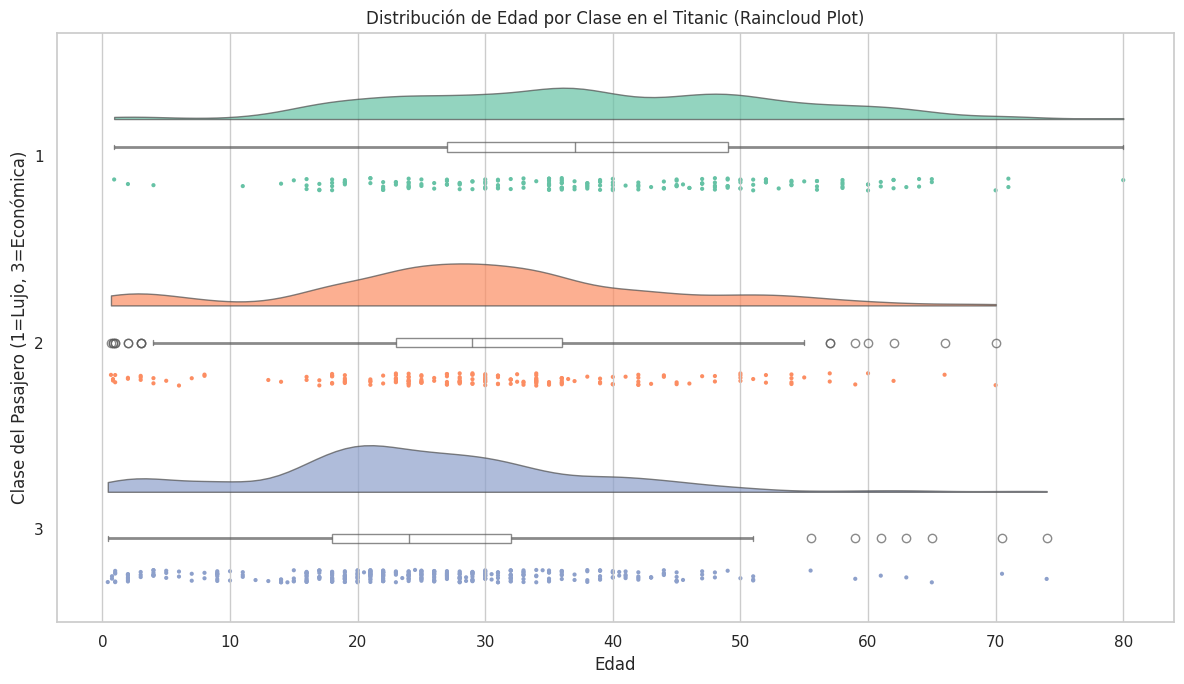

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns

# 1. Cargar el dataset (usamos la URL para asegurar que funcione)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Limpieza rápida: eliminamos filas con edades nulas para que la gráfica sea exacta
df = df.dropna(subset=['Age'])

# 3. Configuración estética
sns.set(style="whitegrid")
plt.figure(figsize=(12, 7))

# 4. Creación de la gráfica
# Analizaremos cómo se distribuye la Edad según la Clase (1ra, 2da, 3ra)
ax = pt.RainCloud(
    x = 'Pclass',
    y = 'Age',
    data = df,
    palette = "Set2",
    bw = 0.2,          # Suavizado de la 'nube'
    width_viol = 0.5,  # Tamaño de la distribución
    orient = "h",      # Horizontal para que se lea mejor la edad
    alpha = 0.7,
    dodge = True,
    move = 0.2
)

# 5. Personalización de títulos
plt.title("Distribución de Edad por Clase en el Titanic (Raincloud Plot)")
plt.xlabel("Edad")
plt.ylabel("Clase del Pasajero (1=Lujo, 3=Económica)")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/ptitprince/PtitPrince.py:1070: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


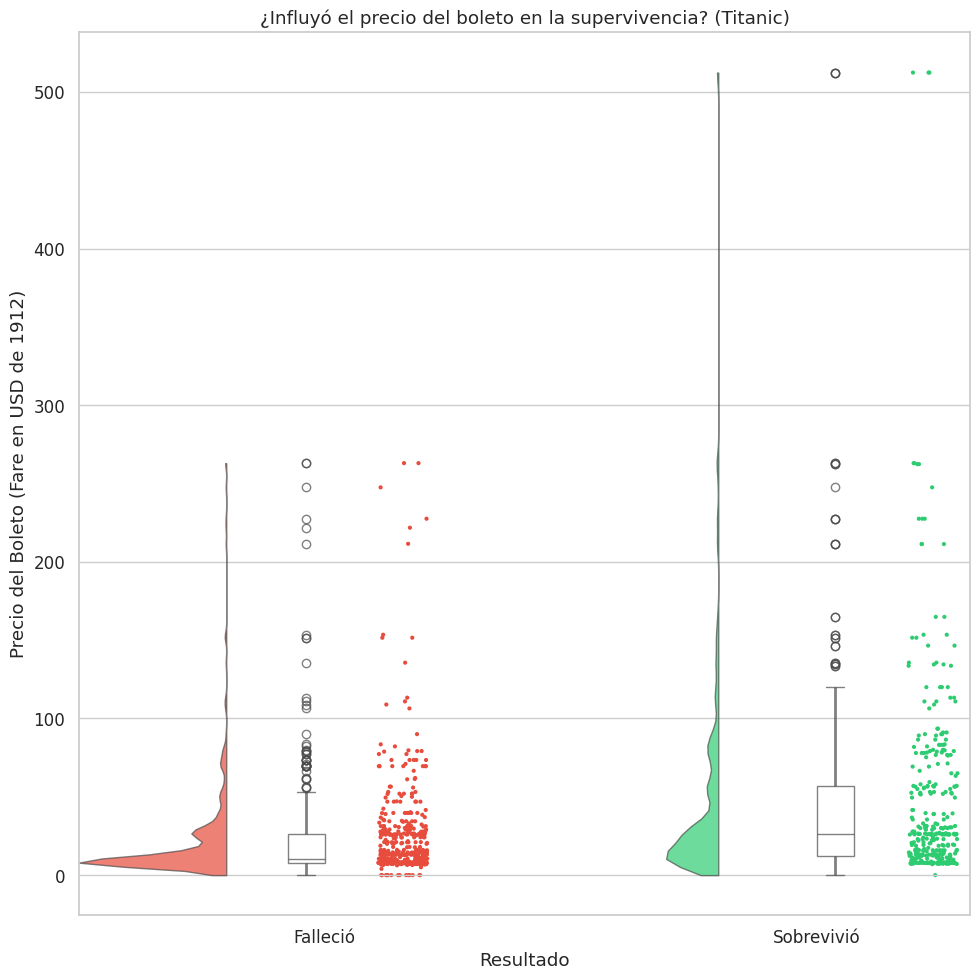

In [5]:
#---------------------------------------------------------------------------------
# INFLUENCIA DEL PRECIO DE BOLETO EN LA SUPERVIVENCIA
#---------------------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns

# 1. Carga de datos desde la URL (Persistencia garantizada en la sesión)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Preparación de etiquetas para que la gráfica sea clara
# Cambiamos 0 y 1 por texto para que el reclutador entienda rápido
df['Survived_Label'] = df['Survived'].map({0: 'Falleció', 1: 'Sobrevivió'})

# 3. Configuración visual
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 10))

# 4. Creación del Raincloud Plot Vertical
ax = pt.RainCloud(
    x = 'Survived_Label',
    y = 'Fare',
    data = df,
    palette = ["#e74c3c", "#2ecc71"], # Rojo para fallecidos, Verde para sobrevivientes
    bw = 0.1,          # Menor bw porque el Fare tiene valores muy extremos
    width_viol = 0.6,
    orient = "v",
    alpha = 0.7,
    dodge = True,
    move = 0.2
)

# 5. Ajustes finales (El Fare tiene outliers muy altos, como 500 USD)
plt.title("¿Influyó el precio del boleto en la supervivencia? (Titanic)")
plt.xlabel("Resultado")
plt.ylabel("Precio del Boleto (Fare en USD de 1912)")

# Opcional: Limitar el eje Y si quieres ver mejor la masa de gente pobre
# plt.ylim(-10, 150)

plt.tight_layout()
plt.show()

"Realicé un análisis de correlación entre el nivel socioeconómico (Fare) y la tasa de supervivencia. Mediante el uso de Raincloud Plots, se evidenció un sesgo positivo de supervivencia hacia los pasajeros con tarifas superiores a 50 USD. La visualización permite confirmar que, aunque la mayoría de los pasajeros pagaron tarifas bajas, la distribución de sobrevivientes tiene una varianza mucho mayor en el gasto, validando la hipótesis de prioridad de evacuación por clase económica."

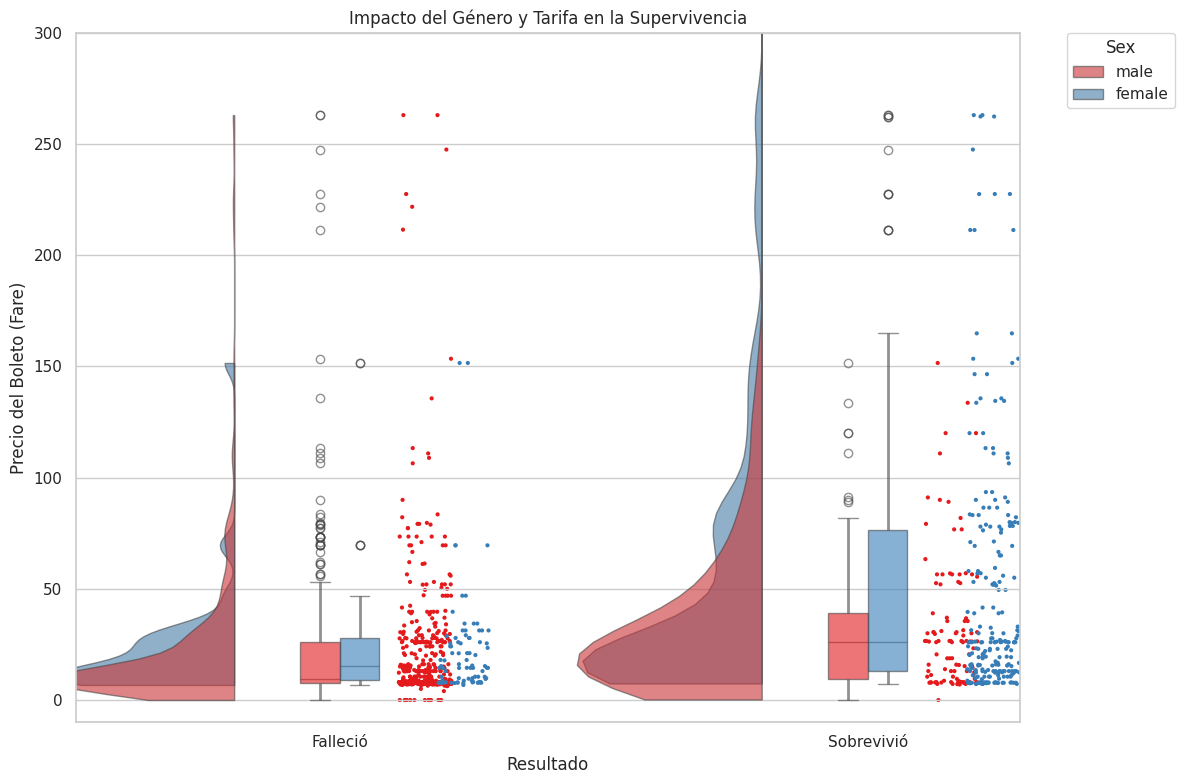

In [6]:
#--------------------------------------------------------------------------------
# IMPACTO DEL GÉNERO Y LA TARIFA EN LA SUPERVIVENCIA
#--------------------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns

# 1. Carga de datos
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df['Survived_Label'] = df['Survived'].map({0: 'Falleció', 1: 'Sobrevivió'})

# 2. Configuración visual
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# 3. Raincloud Plot con 'Hue' (para separar por Género)
ax = pt.RainCloud(
    x = 'Survived_Label',
    y = 'Fare',
    hue = 'Sex',      # <--- Separamos por Hombre/Mujer
    data = df,
    palette = "Set1",
    bw = 0.2,
    width_viol = 0.7,
    orient = "v",
    alpha = 0.6,
    dodge = True,     # <--- Crucial para que no se encimen las nubes
    move = 0.2
)

# 4. Personalización
plt.title("Impacto del Género y Tarifa en la Supervivencia")
plt.xlabel("Resultado")
plt.ylabel("Precio del Boleto (Fare)")
plt.ylim(-10, 300) # Recortamos un poco el tope para ver mejor el grueso de la población

plt.tight_layout()
plt.show()

"Implementé una visualización multivariante utilizando hue y dodge para analizar la intersección entre variables categóricas (Género y Supervivencia) y numéricas (Fare). Este enfoque permite identificar que el protocolo de evacuación priorizó el género sobre el nivel socioeconómico, un fenómeno que se visualiza claramente en la densidad de las nubes y la dispersión de los puntos (jitter)."

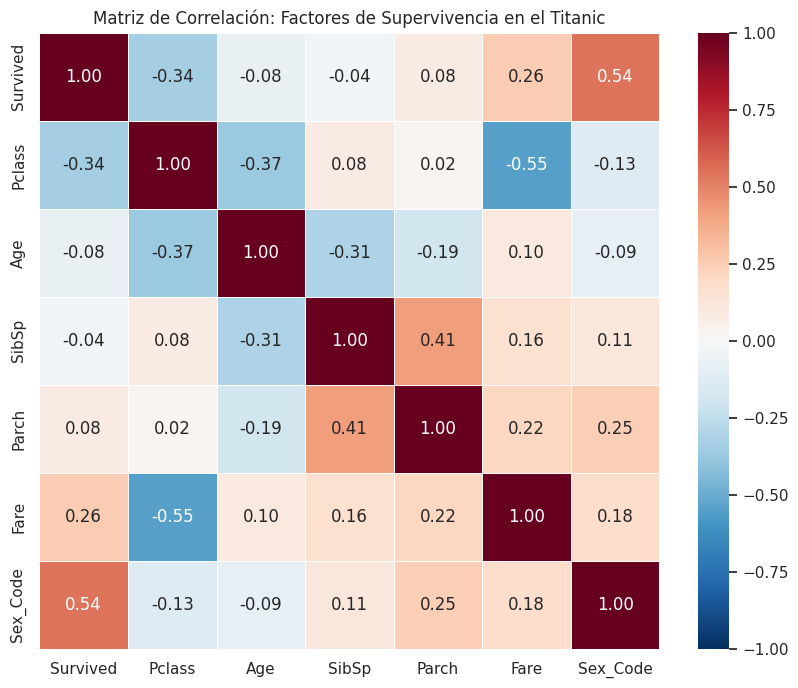

In [7]:
#------------------------------
# MATRIZ DE CORELACIÓN
#------------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga y preparación de datos
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Preprocesamiento: Convertir variables categóricas a numéricas
# Esto es necesario porque la correlación solo funciona con números
df['Sex_Code'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked_Code'] = df['Embarked'].astype('category').cat.codes

# 3. Seleccionamos solo las columnas numéricas relevantes
cols_interes = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_Code']
matriz_corr = df[cols_interes].corr()

# 4. Configuración del Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr,
            annot=True,       # Muestra los números en cada celda
            cmap='RdBu_r',    # Escala de colores (Rojo=Negativo, Azul=Positivo)
            fmt=".2f",        # Dos decimales
            linewidths=0.5,
            vmin=-1, vmax=1)  # Normalizamos la escala de -1 a 1

plt.title("Matriz de Correlación: Factores de Supervivencia en el Titanic")
plt.show()

"La matriz de correlación identifica al Género (0.54) y a la Clase Social (-0.34) como los predictores lineales más robustos para la supervivencia. Asimismo, la fuerte correlación inversa entre Tarifa y Clase (-0.55) valida la consistencia de los datos económicos del dataset"